In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from qiskit.circuit import Instruction
from qiskit import QuantumCircuit, transpile
from quam_libs.components import QuAM
from quam_libs.experiments.qiskit_circuit import run_qua_program_and_return_results, create_target, design_qua_program_from_qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

2025-11-19 16:40:12,522 - qm - INFO     - Starting session: 1b6e5440-f5b8-47d4-800b-262075124175


/Users/ratiswu/miniforge3/envs/DGXQUA/lib/python3.10/site-packages/qm/results/__init__.py:15: DeprecationWarning: qm.results is deprecated since "1.2.3" and will be removed in "1.3.0". If you need anything from this module, import it directly from `qm` or from `qm.simulate` for simulator-related functionality.
  warnings.warn(


In [2]:
simulator = AerSimulator()

machine = QuAM.load()
qmm = machine.connect()
qm = qmm.open_qm(machine.generate_config(), close_other_machines=True)

n_shots = 1024
manual_transpile = True
target_qubit_indices = [0,1,2,3,4] # 0, 1, 2, 3, 4
target_qubits = [machine.active_qubits[i] for i in target_qubit_indices]
for i in target_qubits: print("target qubits: ", i)
for qubit in target_qubits:
    qubit.macros['reset'].reset_type='thermalize'
    qubit.macros['reset'].thermalize_time = qubit.thermalization_time


2025-11-19 16:40:14,544 - qm - INFO     - Performing health check
2025-11-19 16:40:14,556 - qm - INFO     - Cluster healthcheck completed successfully.


/Users/ratiswu/miniforge3/envs/DGXQUA/lib/python3.10/site-packages/quam/core/quam_classes.py:570: UserWarning: No QuamRoot initialized, cannot retrieve absolute reference #/wiring/qubit_pairs/q1-2/c/opx_output from TunableCoupler
  warnings.warn(
/Users/ratiswu/miniforge3/envs/DGXQUA/lib/python3.10/site-packages/quam/core/quam_classes.py:570: UserWarning: No QuamRoot initialized, cannot retrieve absolute reference #/wiring/qubit_pairs/q2-3/c/opx_output from TunableCoupler
  warnings.warn(
/Users/ratiswu/miniforge3/envs/DGXQUA/lib/python3.10/site-packages/quam/core/quam_classes.py:570: UserWarning: No QuamRoot initialized, cannot retrieve absolute reference #/wiring/qubit_pairs/q3-4/c/opx_output from TunableCoupler
  warnings.warn(
/Users/ratiswu/miniforge3/envs/DGXQUA/lib/python3.10/site-packages/quam/core/quam_classes.py:570: UserWarning: No QuamRoot initialized, cannot retrieve absolute reference #/wiring/qubit_pairs/q4-5/c/opx_output from TunableCoupler
  warnings.warn(


target qubits:  Transmon(id='q1', macros={'x': PulseMacro(id='x', pulse='x180'), 'rz': VirtualZMacro(id='rz'), 'sx': PulseMacro(id='sx', pulse='x90'), 'measure': MeasureMacro(id='measure', pulse='readout'), 'reset': ResetMacro(id='reset', reset_type='active', pi_pulse='x180', readout_pulse='readout', max_attempts=15, thermalize_time=0), 'delay': DelayMacro(id='delay'), 'id': IdMacro(id='id')}, xy=MWChannel(operations={'x180_DragCosine': DragCosinePulse(length=16, id=None, digital_marker='ON', axis_angle=0, amplitude=0.4120168230362367, alpha=0.6960161931758533, anharmonicity=207050000, detuning=0.0), 'x90_DragCosine': DragCosinePulse(length=16, id=None, digital_marker='ON', axis_angle=0, amplitude=0.20037683171301876, alpha=0.899999999999999, anharmonicity=207050000, detuning=0.0), '-x90_DragCosine': DragCosinePulse(length=16, id=None, digital_marker='ON', axis_angle=3.141592653589793, amplitude=0.20037683171301876, alpha=0.899999999999999, anharmonicity=207050000, detuning=0.0), 'y180

/Users/ratiswu/miniforge3/envs/DGXQUA/lib/python3.10/site-packages/qm/program/_qua_config_schema.py:1880: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "1.3.0". Please remove it from the Qua config.
  warnings.warn(


In [ ]:
from numpy import pi
qc = QuantumCircuit(len(target_qubits), len(target_qubits))

# # Ry 
qc.ry(pi/3,0)

# # X 
# qc.x(1)
# qc.x(2)
# qc.x(3)
# qc.x(4)

# # H
# qc.h(0)
# qc.h(1)
# qc.h(2)
# qc.h(3)
# qc.h(4)

# # SX
# qc.sx(0)
# qc.sx(1)
# qc.sx(2)
# qc.sx(3)
# qc.sx(4)

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)
qc.measure(3, 3)
qc.measure(4, 4)




{'00001': 250, '00000': 774}


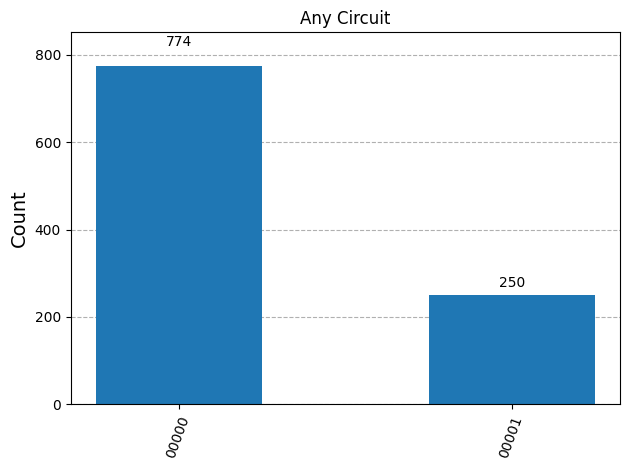

In [13]:
# Simulated QPU: 
circ = transpile(qc, simulator)

# Run and get counts
result = simulator.run(circ, n_shots=n_shots).result()
counts = result.get_counts(circ)
print(counts)
plot_histogram(counts, title='Any Circuit')

global phase: 3π/2
              ┌────────┐┌────┐┌──────────┐┌────┐┌─┐
q_0 -> 0 ─|0>─┤ Rz(-π) ├┤ √X ├┤ Rz(2π/3) ├┤ √X ├┤M├
              └──┬─┬───┘└────┘└──────────┘└────┘└╥┘
q_1 -> 1 ─|0>────┤M├─────────────────────────────╫─
                 └╥┘     ┌─┐                     ║ 
q_2 -> 2 ─|0>─────╫──────┤M├─────────────────────╫─
                  ║      └╥┘      ┌─┐            ║ 
q_3 -> 3 ─|0>─────╫───────╫───────┤M├────────────╫─
                  ║       ║       └╥┘      ┌─┐   ║ 
q_4 -> 4 ─|0>─────╫───────╫────────╫───────┤M├───╫─
                  ║       ║        ║       └╥┘   ║ 
    c: 5/═════════╩═══════╩════════╩════════╩════╩═
                  1       2        3        4    0 
2025-11-19 16:42:06,618 - qm - INFO     - Clearing queue
2025-11-19 16:42:06,630 - qm - INFO     - Adding program to queue.
{'c': {'00000': 607, '00001': 235, '00010': 27, '00011': 13, '00100': 25, '00101': 7, '00110': 3, '00111': 1, '01000': 45, '01001': 18, '01010': 3, '01011': 2, '01100': 2, '01101': 

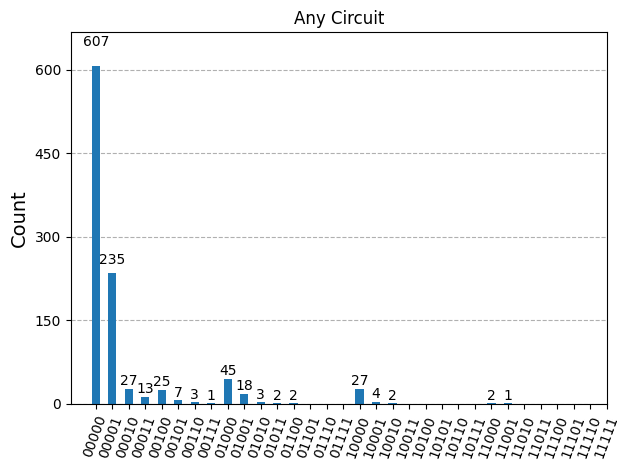

In [14]:
# Run on Real QPU: 
if manual_transpile:
    optimization_level = 1
    target = create_target(machine)
    # Transpile the circuit to the target (Optional: if not done here, will be done in the function generating the program)
    qc = transpile(qc, target=target, initial_layout=target_qubit_indices, optimization_level=optimization_level)
    results = design_qua_program_from_qiskit(qc, machine, n_shots=n_shots)
    results = run_qua_program_and_return_results(results, machine, qc, n_shots, qm)

else:
    optimization_level = 1 # Default optimization level is 1, has to be specified if manual_transpile is False
    results = design_qua_program_from_qiskit(qc, machine, target_qubits, n_shots, optimization_level)
    results = run_qua_program_and_return_results(results, machine, qc, n_shots, qm)

print(results)
plot_histogram(results['c'], title='Any Circuit')

# Results in the form: {'c1": {"00": 512, "11": 512}, "c0": {"00": 512, "11": 512}, ...}

In [66]:
# Close QM connections

qmm.close_all_qms()